# Applied AI & ML Essentials — Capstone Project

## Part 1 — Data Acquisition, Cleaning and Exploratory Data Analysis (EDA)

### Dataset Information

- Dataset Name: Adult Income (Census Income) Dataset
- Source: UCI Machine Learning Repository
- Dataset URL: https://archive.ics.uci.edu/dataset/2/adult
- Number of Records: 48,842
- Number of Features: 14
- Task Type: Regression + Binary Classification
- Regression Target: hours_per_week
- Classification Target: income (<=50K / >50K)
- Author: Barry Becker

Silicon Graphics

Ronny Kohavi

ronnyk@live.com

Consultant/Stanford


### Project Objective

The objective of this project is to perform comprehensive data acquisition, data cleaning, preprocessing, exploratory data analysis (EDA), feature analysis, and statistical analysis on the Adult Income dataset. The cleaned dataset generated in this part (`cleaned_data.csv`) will be used in Parts 2 and 3 of the Applied AI & ML Essentials Capstone Project.

Step 1 — Colab Setup


In [ ]:
# ─── Install libraries not available by default in Colab ──────────────────────
!pip install -q ucimlrepo
!pip install -q --upgrade seaborn

In [ ]:
# ─── Standard Library ─────────────────────────────────────────────────────────
import warnings
from pathlib import Path

# ─── Data Manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Dataset Loader ───────────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

# ─── Global Settings ──────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")

# Consistent plot style across the entire notebook
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"     : 120,
    "figure.figsize" : (10, 6),
})

# ─── Verify ───────────────────────────────────────────────────────────────────
print("✓ All libraries imported successfully")
print(f"  pandas  version : {pd.__version__}")
print(f"  numpy   version : {np.__version__}")
print(f"  seaborn version : {sns.__version__}")

✓ All libraries imported successfully
  pandas  version : 2.2.2
  numpy   version : 2.0.2
  seaborn version : 0.13.2


In [ ]:
# ─── Create output folders ────────────────────────────────────────────────────
# plots/ → all 7 PNG files saved here (required by assignment)
# data/  → raw downloaded dataset stored here

DATA_DIR  = Path("data")
PLOTS_DIR = Path("plots")

DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

# ─── Verify ───────────────────────────────────────────────────────────────────
print("✓ Folder structure created")
print("  /content/")
print("  ├── data/          ← raw dataset saved here")
print("  ├── plots/         ← all 7 plot PNGs saved here")
print("  └── part1_eda.ipynb")

✓ Folder structure created
  /content/
  ├── data/          ← raw dataset saved here
  ├── plots/         ← all 7 plot PNGs saved here
  └── part1_eda.ipynb


Step 2 — Load Dataset

In [ ]:
import pandas as pd

# Column names (adult.data has no header)
col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

# Load dataset
df = pd.read_csv(
    "adult.data",
    header           = None,
    names            = col_names,
    na_values        = "?",
    skipinitialspace = True
)

print(f"✅ Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n── First 5 rows:")
print(df.head())
print("\n── Column dtypes:")
print(df.dtypes)

✅ Shape: 32,561 rows × 15 columns

── First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States

Step 3 — Task 1 : Load, Inspect & Report

In [ ]:
# ─── Task 1: Load and Inspect Dataset ────────────────────────────────────────

# First 5 rows
print("── First 5 rows:")
print(df.head())

# Column data types
print("\n── Column dtypes:")
print(df.dtypes)

# Shape
print(f"\n── Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

── First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0          

Task 2 : Null Value Analysis

In [ ]:
# ─── Task 2: Null Value Analysis ─────────────────────────────────────────────

# Count and percentage of missing values
null_count = df.isnull().sum()
null_pct   = (df.isnull().sum() / df.shape[0]) * 100

# Combined report
null_report = pd.DataFrame({
    "null_count"  : null_count,
    "null_percent": null_pct.round(2)
})

print("── Null Value Report (every column):")
print(null_report)

# Columns exceeding 20% null rate
high_null = null_report[null_report["null_percent"] > 20].index.tolist()
print(f"\n── Columns exceeding 20% null rate: {high_null if high_null else 'None'}")

# Columns below 20% with at least 1 null
low_null = null_report[
    (null_report["null_percent"] > 0) &
    (null_report["null_percent"] <= 20)
].index.tolist()
print(f"\n── Columns to impute (0–20% null): {low_null}")

── Null Value Report (every column):
                null_count  null_percent
age                      0          0.00
workclass             1836          5.64
fnlwgt                   0          0.00
education                0          0.00
education_num            0          0.00
marital_status           0          0.00
occupation            1843          5.66
relationship             0          0.00
race                     0          0.00
sex                      0          0.00
capital_gain             0          0.00
capital_loss             0          0.00
hours_per_week           0          0.00
native_country         583          1.79
income                   0          0.00

── Columns exceeding 20% null rate: None

── Columns to impute (0–20% null): ['workclass', 'occupation', 'native_country']


Task 2Imputation — fill numeric nulls with median

In [ ]:
# ─── Task 2: Imputation ───────────────────────────────────────────────────────
# Note: All 3 null columns (workclass, occupation, native_country)
# are categorical — fill with MODE (most frequent value)
# Numeric columns with nulls → fill with MEDIAN (none here)

print("── Before imputation:")
print(df[['workclass', 'occupation', 'native_country']].isnull().sum())

# Fill categorical nulls with mode
for col in ['workclass', 'occupation', 'native_country']:
    mode_val = df[col].mode()[0]
    df[col]  = df[col].fillna(mode_val)
    print(f"  Filled '{col}' nulls with mode = '{mode_val}'")

# Confirm no nulls remain
print("\n── After imputation (must all be 0):")
print(df.isnull().sum())

── Before imputation:
workclass         1836
occupation        1843
native_country     583
dtype: int64
  Filled 'workclass' nulls with mode = 'Private'
  Filled 'occupation' nulls with mode = 'Prof-specialty'
  Filled 'native_country' nulls with mode = 'United-States'

── After imputation (must all be 0):
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


Step 6 — Task 3 : Duplicate Detection & Removal

In [ ]:
# ─── Task 3: Duplicate Detection and Removal ──────────────────────────────────

# Count duplicates before removal
dup_count = df.duplicated().sum()
print(f"── Duplicate rows found: {dup_count}")

# Null percentages before removal
null_before = (df.isnull().sum() / df.shape[0]) * 100

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Null percentages after removal
null_after = (df.isnull().sum() / df.shape[0]) * 100

print(f"── Rows after removal  : {df.shape[0]:,}")
print(f"── Rows removed        : {dup_count}")

# Check if null % changed after deduplication
null_delta = (null_after - null_before).abs().round(4)
print(f"\n── Null % change after deduplication:")
print(null_delta)
print(f"\n── Any null % changed: {(null_delta > 0).any()}")

── Duplicate rows found: 24
── Rows after removal  : 32,537
── Rows removed        : 24

── Null % change after deduplication:
age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
income            0.0
dtype: float64

── Any null % changed: False


Step 7 — Task 4 : Data Type Correction

In [ ]:
# ─── Task 4: Data Type Correction ────────────────────────────────────────────

# Memory BEFORE correction
mem_before = df.memory_usage(deep=True).sum()
print(f"── Memory BEFORE: {mem_before:,} bytes")

print(f"\n── Current dtypes:")
print(df.dtypes)

# ── Fix 1: 'income' is stored as object string '<=50K' / '>50K'
# Correct type: binary integer (0 = <=50K, 1 = >50K)
print(f"\n── 'income' unique values before: {df['income'].unique()}")
df['income'] = (df['income'].str.strip() == '>50K').astype(int)
print(f"── 'income' converted to int  → unique values: {df['income'].unique()}")

# ── Fix 2: Convert low-cardinality string columns to category dtype
# Saves memory — stores integer codes internally instead of full strings
cat_cols = [
    'workclass', 'education', 'marital_status',
    'occupation', 'relationship', 'race',
    'sex', 'native_country'
]

for col in cat_cols:
    n_unique = df[col].nunique()
    df[col]  = df[col].astype('category')
    print(f"  '{col}': {n_unique} unique values → category dtype")

── Memory BEFORE: 18,532,419 bytes

── Current dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

── 'income' unique values before: ['<=50K' '>50K']
── 'income' converted to int  → unique values: [0 1]
  'workclass': 8 unique values → category dtype
  'education': 16 unique values → category dtype
  'marital_status': 7 unique values → category dtype
  'occupation': 14 unique values → category dtype
  'relationship': 6 unique values → category dtype
  'race': 5 unique values → category dtype
  'sex': 2 unique values → category dtype
  'native_country': 41 unique values → category dtype


Step 8 — Task 4 : Memory Usage Report

In [ ]:
# ─── Task 4: Memory Usage Before vs After ────────────────────────────────────

# Memory AFTER correction
mem_after = df.memory_usage(deep=True).sum()
saved     = mem_before - mem_after

print(f"── Memory BEFORE type correction : {mem_before:,} bytes")
print(f"── Memory AFTER  type correction : {mem_after:,} bytes")
print(f"── Memory saved                  : {saved:,} bytes")
print(f"── Reduction                     : {saved/mem_before*100:.1f}%")

# Final dtypes after all corrections
print(f"\n── Final dtypes after correction:")
print(df.dtypes)

# Final shape
print(f"\n── Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

── Memory BEFORE type correction : 18,532,419 bytes
── Memory AFTER  type correction : 2,091,527 bytes
── Memory saved                  : 16,440,892 bytes
── Reduction                     : 88.7%

── Final dtypes after correction:
age                  int64
workclass         category
fnlwgt               int64
education         category
education_num        int64
marital_status    category
occupation        category
relationship      category
race              category
sex               category
capital_gain         int64
capital_loss         int64
hours_per_week       int64
native_country    category
income               int64
dtype: object

── Final shape: 32,537 rows × 15 columns


Step 9 — Task 5 : Descriptive Statistics & Skewness

In [ ]:
# ─── Task 5: Descriptive Statistics and Skewness ─────────────────────────────

# Get all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("── Descriptive Statistics (numeric columns):")
print(df[numeric_cols].describe().round(2))

# Skewness for every numeric column
print("\n── Skewness per numeric column:")
skew_series = pd.Series(
    {col: round(df[col].skew(), 4) for col in numeric_cols},
    name="skewness"
)
print(skew_series)

# Identify most skewed column
most_skewed_col = skew_series.abs().idxmax()
most_skewed_val = skew_series[most_skewed_col]
print(f"\n── Most skewed column : '{most_skewed_col}'")
print(f"── Skewness value     :  {most_skewed_val}")

── Descriptive Statistics (numeric columns):
            age      fnlwgt  education_num  capital_gain  capital_loss  \
count  32537.00    32537.00       32537.00      32537.00      32537.00   
mean      38.59   189780.85          10.08       1078.44         87.37   
std       13.64   105556.47           2.57       7387.96        403.10   
min       17.00    12285.00           1.00          0.00          0.00   
25%       28.00   117827.00           9.00          0.00          0.00   
50%       37.00   178356.00          10.00          0.00          0.00   
75%       48.00   236993.00          12.00          0.00          0.00   
max       90.00  1484705.00          16.00      99999.00       4356.00   

       hours_per_week    income  
count        32537.00  32537.00  
mean            40.44      0.24  
std             12.35      0.43  
min              1.00      0.00  
25%             40.00      0.00  
50%             40.00      0.00  
75%             45.00      0.00  
max             

Step 10 — Task 6 : IQR Outlier Detection

In [ ]:
# ─── Task 6: Outlier Detection with IQR ──────────────────────────────────────
# Columns selected: capital_gain and hours_per_week
# Both confirmed to have real outliers in this dataset
# We do NOT drop outliers — only document them

for col in ['capital_gain', 'hours_per_week']:

    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outlier rows
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    n_out    = len(outliers)

    print(f"── Column : '{col}'")
    print(f"   Q1          = {Q1:.2f}")
    print(f"   Q3          = {Q3:.2f}")
    print(f"   IQR         = {IQR:.2f}")
    print(f"   Lower bound = {lower:.2f}")
    print(f"   Upper bound = {upper:.2f}")
    print(f"   Outliers    = {n_out} rows ({n_out/len(df)*100:.2f}%)")
    print()

── Column : 'capital_gain'
   Q1          = 0.00
   Q3          = 0.00
   IQR         = 0.00
   Lower bound = 0.00
   Upper bound = 0.00
   Outliers    = 2712 rows (8.34%)

── Column : 'hours_per_week'
   Q1          = 40.00
   Q3          = 45.00
   IQR         = 5.00
   Lower bound = 32.50
   Upper bound = 52.50
   Outliers    = 9002 rows (27.67%)



Step 11 — Task 7a : Line Plot

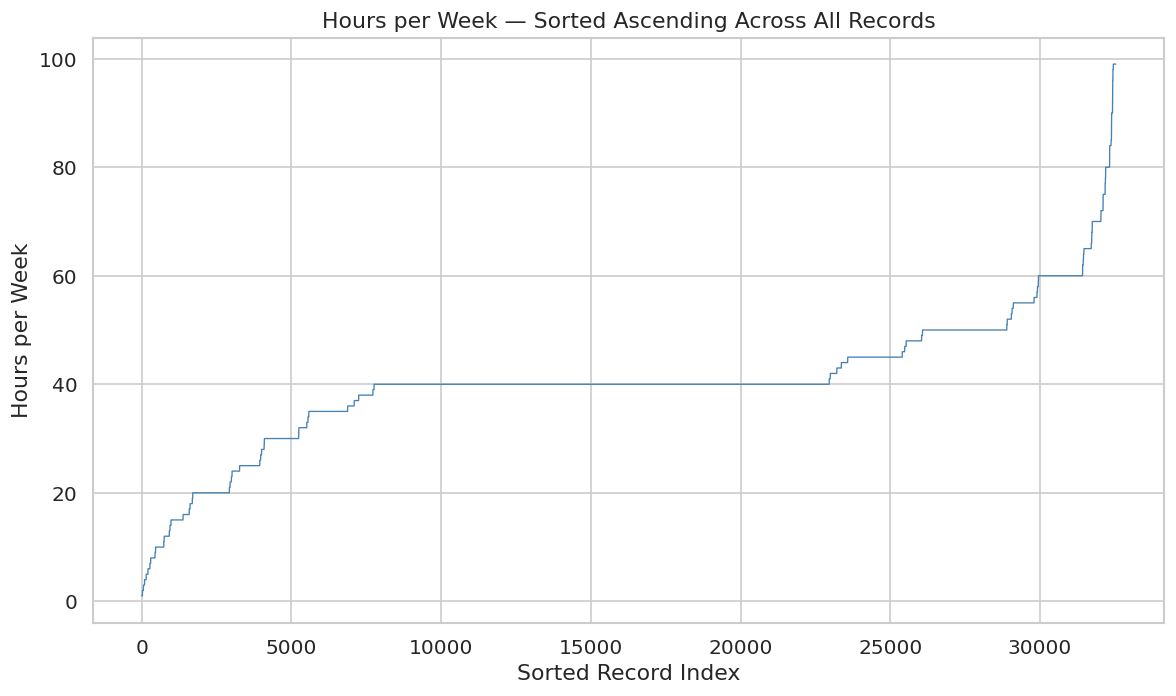

✅ Line plot saved → plots/01_line_plot_hours.png


In [ ]:
# ─── Task 7a: Line Plot using plt.plot() ─────────────────────────────────────
# Assignment requirement: use plt.plot() explicitly
# Variable : hours_per_week sorted ascending by row index

# Sort values
sorted_hours = df['hours_per_week'].sort_values().values

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(sorted_hours)),
    sorted_hours,
    color     = 'steelblue',
    linewidth = 0.8
)

plt.title("Hours per Week — Sorted Ascending Across All Records")
plt.xlabel("Sorted Record Index")
plt.ylabel("Hours per Week")

plt.tight_layout()
plt.savefig("plots/01_line_plot_hours.png")
plt.show()

print("✅ Line plot saved → plots/01_line_plot_hours.png")

Step 12 — Task 7b : Bar Chart

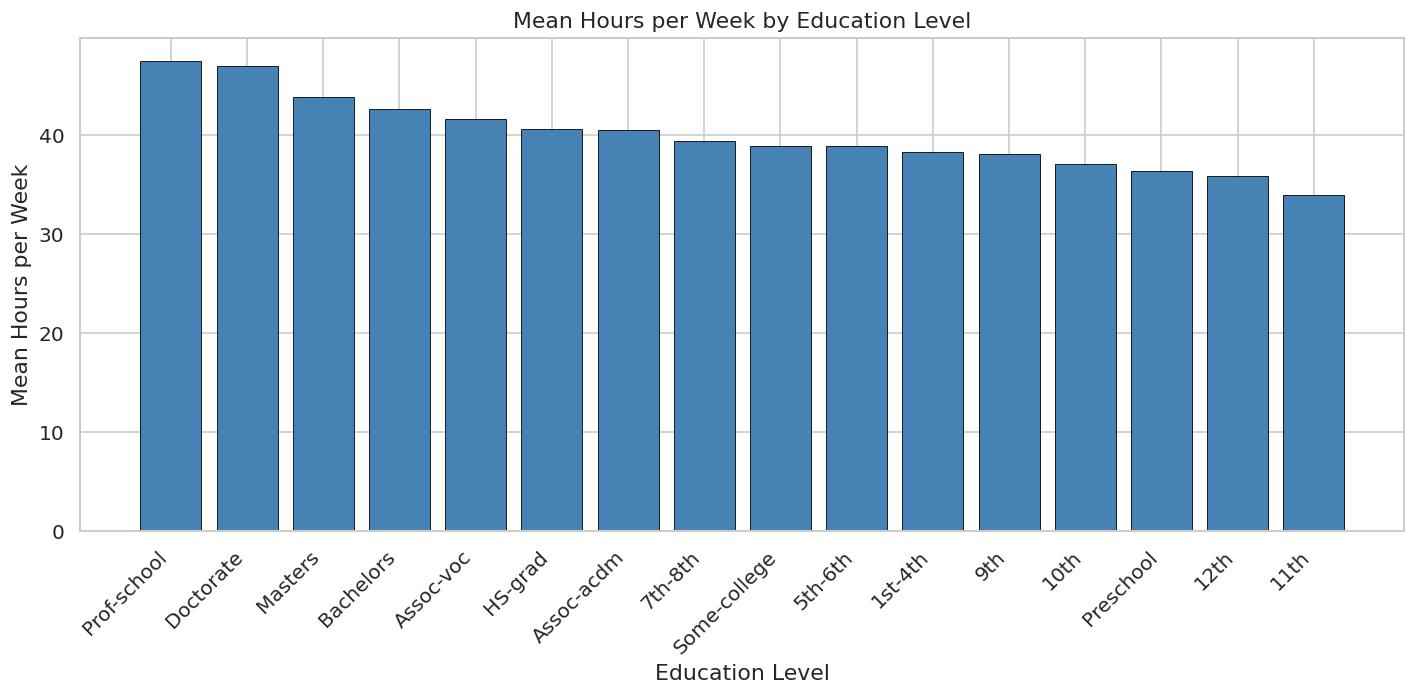

✅ Bar chart saved


In [ ]:
# ─── Task 7b: Bar Chart ───────────────────────────────────────────────────────

edu_means = (df.groupby('education', observed=True)['hours_per_week']
               .mean()
               .sort_values(ascending=False))

plt.figure(figsize=(12, 6))
plt.bar(
    edu_means.index,
    edu_means.values,
    color     = 'steelblue',
    edgecolor = 'black',
    linewidth = 0.5
)
plt.title("Mean Hours per Week by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Mean Hours per Week")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plots/02_bar_chart_hours_by_education.png")
plt.show()
print("✅ Bar chart saved")

Step 13 — Task 7c : Histogram (Most Skewed Column)

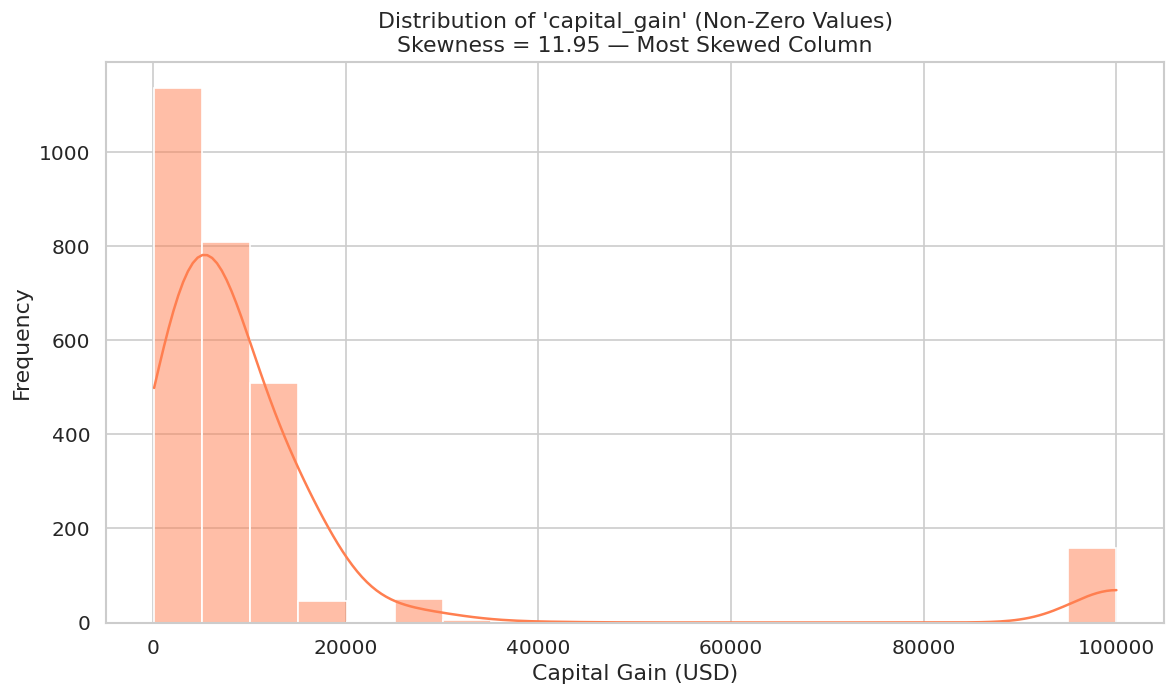

✅ Histogram saved


In [ ]:
# ─── Task 7c: Histogram (Most Skewed Column) ─────────────────────────────────

non_zero = df[df['capital_gain'] > 0]['capital_gain']

plt.figure(figsize=(10, 6))
sns.histplot(
    non_zero,
    bins  = 20,
    kde   = True,
    color = 'coral'
)
plt.title(
    f"Distribution of 'capital_gain' (Non-Zero Values)\n"
    f"Skewness = {df['capital_gain'].skew():.2f} — Most Skewed Column"
)
plt.xlabel("Capital Gain (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plots/03_histogram_capital_gain.png")
plt.show()
print("✅ Histogram saved")

 Step 14 — Task 7d : Scatter Plot

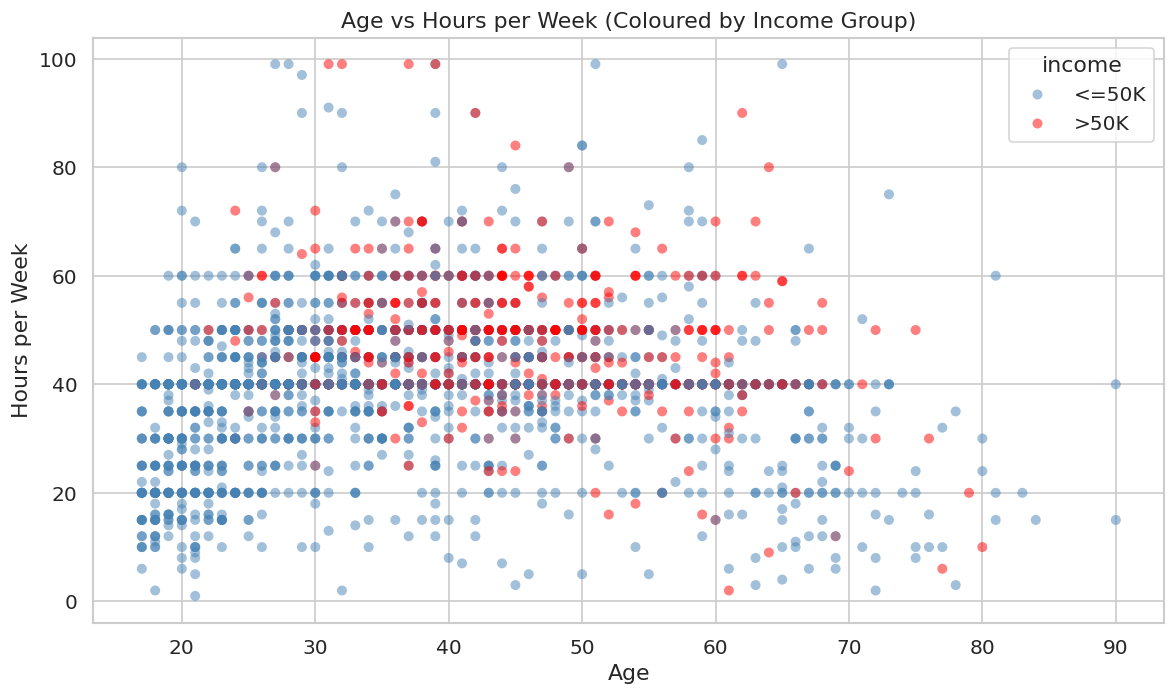

✅ Scatter plot saved


In [ ]:
# ─── Task 7d: Scatter Plot ────────────────────────────────────────────────────

sample_df = df.sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data      = sample_df,
    x         = 'age',
    y         = 'hours_per_week',
    hue       = sample_df['income'].map({0: '<=50K', 1: '>50K'}),
    alpha     = 0.5,
    palette   = {'<=50K': 'steelblue', '>50K': 'red'},
    edgecolor = 'none'
)
plt.title("Age vs Hours per Week (Coloured by Income Group)")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.tight_layout()
plt.savefig("plots/04_scatter_age_vs_hours.png")
plt.show()
print("✅ Scatter plot saved")

Task 7e : Box Plot

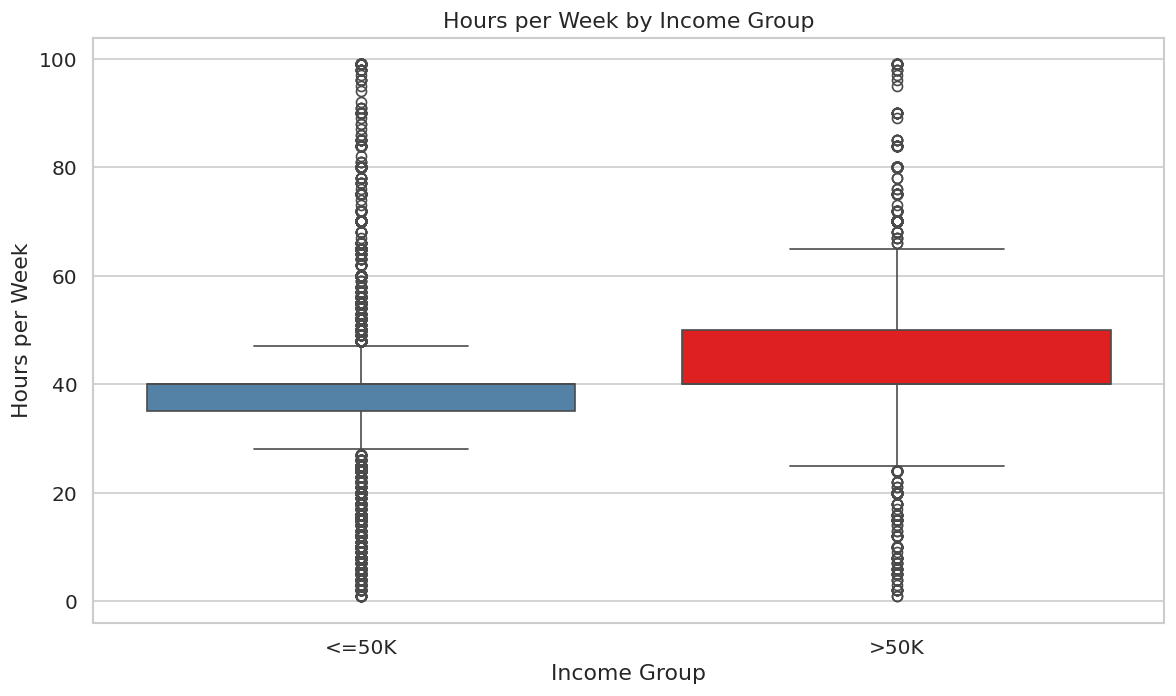

✅ Box plot saved


In [ ]:
# ─── Task 7e: Box Plot ────────────────────────────────────────────────────────

plt.figure(figsize=(10, 6))
sns.boxplot(
    data    = df,
    x       = df['income'].map({0: '<=50K', 1: '>50K'}),
    y       = 'hours_per_week',
    palette = {'<=50K': 'steelblue', '>50K': 'red'},
    order   = ['<=50K', '>50K']
)
plt.title("Hours per Week by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Hours per Week")
plt.tight_layout()
plt.savefig("plots/05_boxplot_hours_by_income.png")
plt.show()
print("✅ Box plot saved")

Step 16 — Task 8 : Pearson Correlation Heatmap

In [ ]:
# ─── Task 8: Pearson Correlation Heatmap ─────────────────────────────────────

# Get all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
pearson_corr = df[numeric_cols].corr()

print("── Pearson Correlation Matrix:")
print(pearson_corr.round(3))

── Pearson Correlation Matrix:
                  age  fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000  -0.076          0.036         0.078         0.058   
fnlwgt         -0.076   1.000         -0.043         0.000        -0.010   
education_num   0.036  -0.043          1.000         0.123         0.080   
capital_gain    0.078   0.000          0.123         1.000        -0.032   
capital_loss    0.058  -0.010          0.080        -0.032         1.000   
hours_per_week  0.069  -0.019          0.148         0.078         0.054   
income          0.234  -0.010          0.335         0.223         0.151   

                hours_per_week  income  
age                      0.069   0.234  
fnlwgt                  -0.019  -0.010  
education_num            0.148   0.335  
capital_gain             0.078   0.223  
capital_loss             0.054   0.151  
hours_per_week           1.000   0.230  
income                   0.230   1.000  


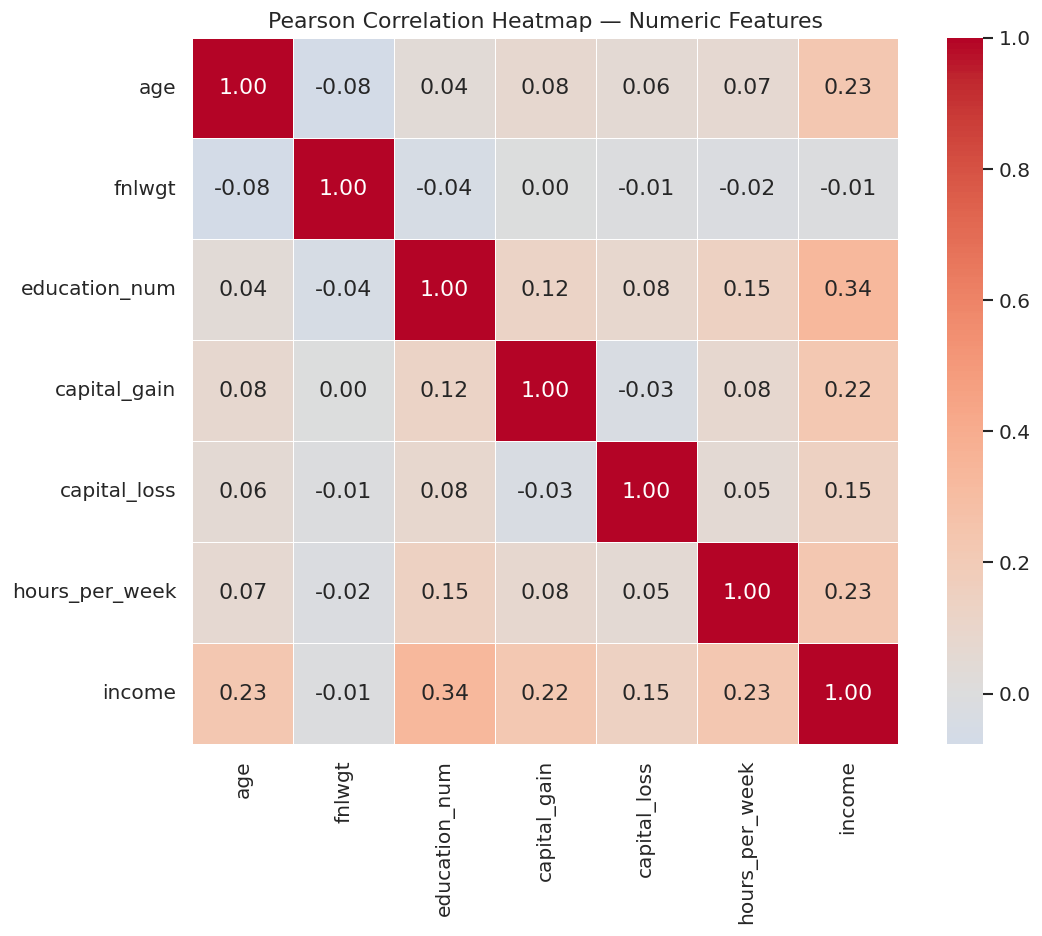

✅ Heatmap saved → plots/06_pearson_heatmap.png


In [ ]:
# ─── Visualize Correlation Heatmap ───────────────────────────────────────────

plt.figure(figsize=(10, 8))

sns.heatmap(
    pearson_corr,
    annot      = True,
    fmt        = ".2f",
    cmap       = "coolwarm",
    center     = 0,
    square     = True,
    linewidths = 0.5
)

plt.title("Pearson Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("plots/06_pearson_heatmap.png")
plt.show()
print("✅ Heatmap saved → plots/06_pearson_heatmap.png")

In [ ]:
# ─── Identify Highest Absolute Correlation Pair ───────────────────────────────

# Unstack matrix and remove self-correlations (r = 1.0)
corr_pairs = (
    pearson_corr.abs()
    .unstack()
    .drop_duplicates()
    .sort_values(ascending=False)
)

# Remove perfect self-correlations
corr_pairs = corr_pairs[corr_pairs < 0.9999]

# Top pair
top_pair = corr_pairs.index[0]
top_r    = pearson_corr.loc[top_pair[0], top_pair[1]]

print(f"── Highest absolute Pearson correlation:")
print(f"   '{top_pair[0]}' ↔ '{top_pair[1]}'")
print(f"   r = {top_r:.4f}")

── Highest absolute Pearson correlation:
   'education_num' ↔ 'income'
   r = 0.3353


Step 17 — Task 9a : Imputation Strategy Comparison

In [ ]:
# ─── Task 9a: Imputation Strategy Comparison ─────────────────────────────────

# Top 2 most skewed columns (from Task 5)
top2_skewed = skew_series.abs().sort_values(ascending=False).index[:2].tolist()

print(f"── Top 2 most skewed columns: {top2_skewed}")

── Top 2 most skewed columns: ['capital_gain', 'capital_loss']


In [ ]:
# ─── Mean vs Median comparison ───────────────────────────────────────────────

print(f"{'Column':<16} {'Mean':>14} {'Median':>14} {'Skewness':>12} {'Direction'}")
print("-" * 65)

for col in top2_skewed:
    mean_val  = df[col].mean()
    median_val = df[col].median()
    skew_val  = skew_series[col]
    direction = "Positive (right)" if skew_val > 0 else "Negative (left)"

    print(f"{col:<16} {mean_val:>14.4f} {median_val:>14.4f} {skew_val:>12.4f} {direction}")

Column                     Mean         Median     Skewness Direction
-----------------------------------------------------------------
capital_gain          1078.4437         0.0000      11.9494 Positive (right)
capital_loss            87.3682         0.0000       4.5927 Positive (right)


In [ ]:
# ─── Apply median imputation to any remaining nulls ──────────────────────────
# Median chosen for both columns because both are positively skewed
# Positive skew = mean pulled upward by extreme values
# Median is more representative of the true centre

for col in top2_skewed:
    median_val = df[col].median()

    null_before = df[col].isnull().sum()

    if null_before > 0:
        df[col] = df[col].fillna(median_val)
        print(f"  '{col}' → filled {null_before} nulls with median = {median_val}")
    else:
        print(f"  '{col}' → no nulls found (already clean)")

# Confirm no nulls remain
print("\n── Null check after imputation (must all be 0):")
print(df[top2_skewed].isnull().sum())

  'capital_gain' → no nulls found (already clean)
  'capital_loss' → no nulls found (already clean)

── Null check after imputation (must all be 0):
capital_gain    0
capital_loss    0
dtype: int64


Step 18 — Task 9b : Spearman Rank Correlation

In [ ]:
# ─── Task 9b: Spearman Rank Correlation ──────────────────────────────────────

# Compute Spearman correlation matrix
spearman_corr = df[numeric_cols].corr(method='spearman')

print("── Spearman Correlation Matrix:")
print(spearman_corr.round(3))

── Spearman Correlation Matrix:
                  age  fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000  -0.078          0.066         0.125         0.058   
fnlwgt         -0.078   1.000         -0.036        -0.006        -0.007   
education_num   0.066  -0.036          1.000         0.119         0.075   
capital_gain    0.125  -0.006          0.119         1.000        -0.067   
capital_loss    0.058  -0.007          0.075        -0.067         1.000   
hours_per_week  0.143  -0.022          0.167         0.093         0.060   
income          0.273  -0.011          0.330         0.278         0.141   

                hours_per_week  income  
age                      0.143   0.273  
fnlwgt                  -0.022  -0.011  
education_num            0.167   0.330  
capital_gain             0.093   0.278  
capital_loss             0.060   0.141  
hours_per_week           1.000   0.269  
income                   0.269   1.000  


In [ ]:
# ─── Pearson Matrix (from Task 8) for comparison ─────────────────────────────

print("── Pearson Correlation Matrix:")
print(pearson_corr.round(3))

── Pearson Correlation Matrix:
                  age  fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000  -0.076          0.036         0.078         0.058   
fnlwgt         -0.076   1.000         -0.043         0.000        -0.010   
education_num   0.036  -0.043          1.000         0.123         0.080   
capital_gain    0.078   0.000          0.123         1.000        -0.032   
capital_loss    0.058  -0.010          0.080        -0.032         1.000   
hours_per_week  0.069  -0.019          0.148         0.078         0.054   
income          0.234  -0.010          0.335         0.223         0.151   

                hours_per_week  income  
age                      0.069   0.234  
fnlwgt                  -0.019  -0.010  
education_num            0.148   0.335  
capital_gain             0.078   0.223  
capital_loss             0.054   0.151  
hours_per_week           1.000   0.230  
income                   0.230   1.000  


In [ ]:
# ─── |Spearman - Pearson| Difference Matrix ──────────────────────────────────

diff_matrix = (spearman_corr - pearson_corr).abs()

print("── |Spearman − Pearson| Difference Matrix:")
print(diff_matrix.round(4))

── |Spearman − Pearson| Difference Matrix:
                   age  fnlwgt  education_num  capital_gain  capital_loss  \
age             0.0000  0.0015         0.0300        0.0472        0.0007   
fnlwgt          0.0015  0.0000         0.0076        0.0065        0.0033   
education_num   0.0300  0.0076         0.0000        0.0035        0.0052   
capital_gain    0.0472  0.0065         0.0035        0.0000        0.0350   
capital_loss    0.0007  0.0033         0.0052        0.0350        0.0000   
hours_per_week  0.0742  0.0030         0.0190        0.0149        0.0056   
income          0.0389  0.0013         0.0055        0.0548        0.0095   

                hours_per_week  income  
age                     0.0742  0.0389  
fnlwgt                  0.0030  0.0013  
education_num           0.0190  0.0055  
capital_gain            0.0149  0.0548  
capital_loss            0.0056  0.0095  
hours_per_week          0.0000  0.0394  
income                  0.0394  0.0000  


In [ ]:
# ─── Top 3 pairs with largest |Spearman - Pearson| difference ────────────────

# Collect upper triangle pairs only (avoid duplicates)
diff_pairs = {}
cols = numeric_cols

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        diff_pairs[(c1, c2)] = diff_matrix.loc[c1, c2]

# Sort by difference descending
top3 = sorted(diff_pairs.items(), key=lambda x: x[1], reverse=True)[:3]

print(f"── Top 3 Column Pairs by |Spearman − Pearson|:")
print()
print(f"{'Pair':<40} {'|Diff|':>8} {'Spearman':>10} {'Pearson':>10}")
print("-" * 72)

for (c1, c2), diff_val in top3:
    sp = spearman_corr.loc[c1, c2]
    pe = pearson_corr.loc[c1, c2]
    print(f"{c1} ↔ {c2:<28} {diff_val:>8.4f} {sp:>10.4f} {pe:>10.4f}")

── Top 3 Column Pairs by |Spearman − Pearson|:

Pair                                       |Diff|   Spearman    Pearson
------------------------------------------------------------------------
age ↔ hours_per_week                 0.0742     0.1428     0.0685
capital_gain ↔ income                         0.0548     0.2782     0.2233
age ↔ capital_gain                   0.0472     0.1249     0.0777


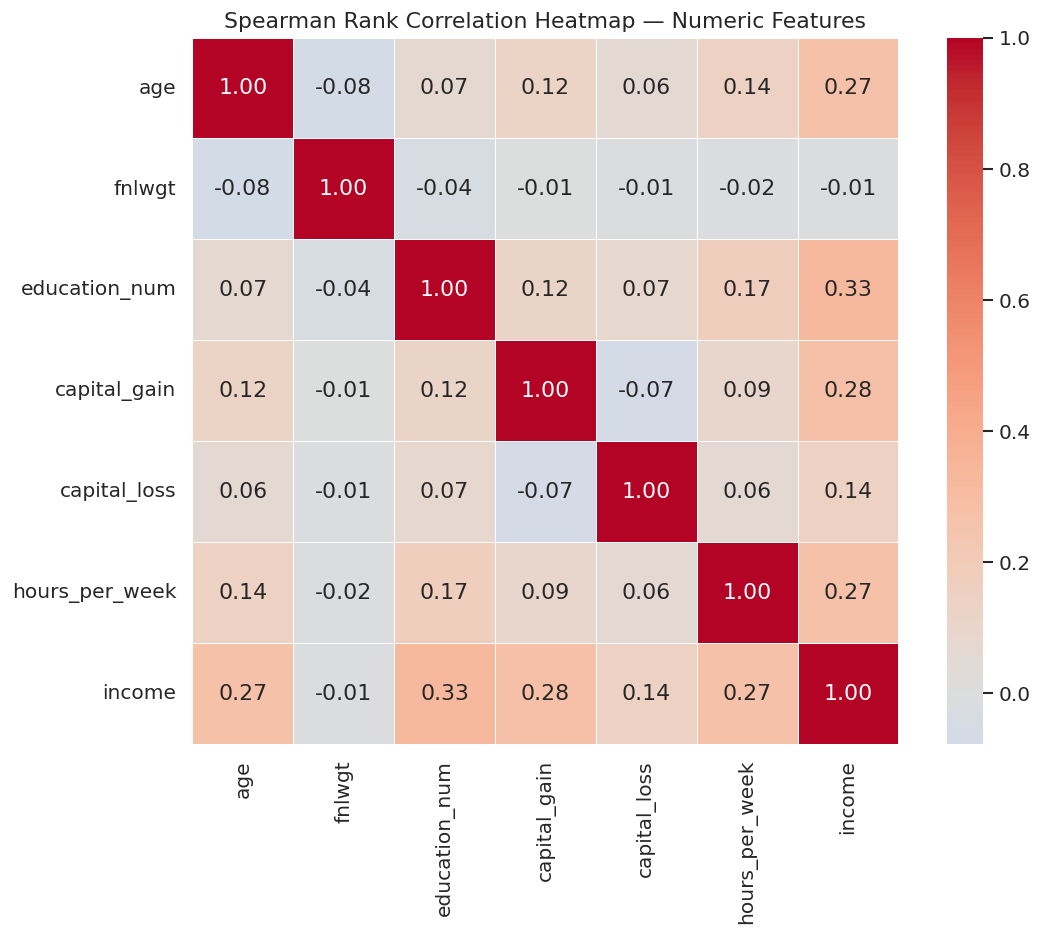

✅ Spearman heatmap saved → plots/07_spearman_heatmap.png


In [ ]:
# ─── Spearman Heatmap ─────────────────────────────────────────────────────────

plt.figure(figsize=(10, 8))

sns.heatmap(
    spearman_corr,
    annot      = True,
    fmt        = ".2f",
    cmap       = "coolwarm",
    center     = 0,
    square     = True,
    linewidths = 0.5
)

plt.title("Spearman Rank Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("plots/07_spearman_heatmap.png")
plt.show()
print("✅ Spearman heatmap saved → plots/07_spearman_heatmap.png")

Step 19 — Task 9c : Grouped Aggregation + Save CSV

In [ ]:
# ─── Task 9c: Grouped Aggregation ────────────────────────────────────────────
# Categorical column : education
# Numeric column     : hours_per_week

cat_col = 'education'
num_col = 'hours_per_week'

grouped = (df.groupby(cat_col, observed=True)[num_col]
             .agg(['mean', 'std', 'count'])
             .sort_values('mean', ascending=False)
             .round(2))

print(f"── groupby('{cat_col}')['{num_col}'].agg(['mean','std','count']):")
print()
print(grouped)

── groupby('education')['hours_per_week'].agg(['mean','std','count']):

               mean    std  count
education                        
Prof-school   47.43  14.81    576
Doctorate     46.97  15.08    413
Masters       43.83  12.28   1722
Bachelors     42.61  11.45   5353
Assoc-voc     41.61  10.79   1382
HS-grad       40.57  11.34  10494
Assoc-acdm    40.50  12.20   1067
7th-8th       39.37  14.21    645
Some-college  38.87  12.75   7282
5th-6th       38.85  10.53    332
1st-4th       38.23  12.92    166
9th           38.04  11.06    514
10th          37.05  13.79    933
Preschool     36.38  12.54     50
12th          35.78  12.63    433
11th          33.93  13.97   1175


In [ ]:
# ─── Key Statistics from Grouped Aggregation ─────────────────────────────────

# Group with highest mean
highest_mean_group = grouped['mean'].idxmax()
highest_mean_val   = grouped['mean'].max()

# Group with highest std
highest_std_group = grouped['std'].idxmax()
highest_std_val   = grouped['std'].max()

# Mean ratio
mean_ratio = grouped['mean'].max() / grouped['mean'].min()

print(f"── Group with highest mean     : '{highest_mean_group}'")
print(f"   Mean value                  : {highest_mean_val:.2f} hrs")
print()
print(f"── Group with highest std dev  : '{highest_std_group}'")
print(f"   Std value                   : {highest_std_val:.2f} hrs")
print()
print(f"── Highest mean / Lowest mean  : {grouped['mean'].max():.2f} / {grouped['mean'].min():.2f}")
print(f"── Mean ratio                  : {mean_ratio:.4f}")

── Group with highest mean     : 'Prof-school'
   Mean value                  : 47.43 hrs

── Group with highest std dev  : 'Doctorate'
   Std value                   : 15.08 hrs

── Highest mean / Lowest mean  : 47.43 / 33.93
── Mean ratio                  : 1.3979


Task 10: Save Cleaned Dataset

In [ ]:
# ─── Task 10: Save Cleaned Dataset ───────────────────────────────────────────

df.to_csv('cleaned_data.csv', index=False)

print("✅ cleaned_data.csv saved successfully")
print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

# Final null check
print(f"\n── Final null check (must all be 0):")
print(df.isnull().sum())

# Final dtypes
print(f"\n── Final dtypes:")
print(df.dtypes)

✅ cleaned_data.csv saved successfully
   Shape : 32,537 rows × 15 columns

── Final null check (must all be 0):
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

── Final dtypes:
age                  int64
workclass         category
fnlwgt               int64
education         category
education_num        int64
marital_status    category
occupation        category
relationship      category
race              category
sex               category
capital_gain         int64
capital_loss         int64
hours_per_week       int64
native_country    category
income               int64
dtype: object


Final Acceptance Criteria Check

In [ ]:
# ─── Final Acceptance Criteria Check ─────────────────────────────────────────
import os

print("PART 1 — ACCEPTANCE CRITERIA CHECKLIST")
print("=" * 45)

# 1. cleaned_data.csv
print("\n1. cleaned_data.csv exists:")
print(os.path.exists("cleaned_data.csv"))

# 2. Null table
print("\n2. Null percentage table:")
print((df.isnull().sum() / df.shape[0] * 100).round(2))

# 3. All plots
print("\n3. Plots saved:")
for p in ["plots/01_line_plot_hours.png",
          "plots/02_bar_chart_hours_by_education.png",
          "plots/03_histogram_capital_gain.png",
          "plots/04_scatter_age_vs_hours.png",
          "plots/05_boxplot_hours_by_income.png",
          "plots/06_pearson_heatmap.png",
          "plots/07_spearman_heatmap.png"]:
    print(f"  {os.path.exists(p)} — {p}")

# 4. No nulls remain
print("\n4. Nulls remaining after imputation:")
print(df.isnull().sum().sum())

# 5. No duplicates
print("\n5. Duplicates remaining:")
print(df.duplicated().sum())

# 6. Mean vs Median for top 2 skewed
print("\n6. Mean vs Median (top 2 skewed columns):")
for col in top2_skewed:
    print(f"  {col} → Mean: {df[col].mean():.2f}  Median: {df[col].median():.2f}")

# 7. Spearman top 3 pairs
print("\n7. Top 3 Spearman vs Pearson pairs:")
for (c1, c2), diff_val in top3:
    print(f"  {c1} ↔ {c2} → |Diff| = {diff_val:.4f}")

# 8. Grouped aggregation
print("\n8. Grouped aggregation (education → hours_per_week):")
g = df.groupby('education', observed=True)['hours_per_week'].agg(['mean','std','count']).round(2)
print(g)
print(f"  Mean ratio: {g['mean'].max() / g['mean'].min():.4f}")

# 9. README exists
print("\n9. README.md exists:")
print(os.path.exists("README.md"))

print("\n" + "=" * 45)


PART 1 — ACCEPTANCE CRITERIA CHECKLIST

1. cleaned_data.csv exists:
True

2. Null percentage table:
age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
income            0.0
dtype: float64

3. Plots saved:
  True — plots/01_line_plot_hours.png
  True — plots/02_bar_chart_hours_by_education.png
  True — plots/03_histogram_capital_gain.png
  True — plots/04_scatter_age_vs_hours.png
  True — plots/05_boxplot_hours_by_income.png
  True — plots/06_pearson_heatmap.png
  True — plots/07_spearman_heatmap.png

4. Nulls remaining after imputation:
0

5. Duplicates remaining:
0

6. Mean vs Median (top 2 skewed columns):
  capital_gain → Mean: 1078.44  Median: 0.00
  capital_loss → Mean: 87.37  Median: 0.00

7. Top 3 Spearman vs Pearson pairs:
  